# Notebook for Loading and Plotting Degradation Data
#### Created in October 2022 by Dr Niall Kirkaldy for use with data in the Zenodo repository: 10.5281/zenodo.7235858
-------------------------

This notebook was made to aid in the further use of the lithium-ion battery cycle ageing data saved in the Zenodo repository 10.5281/zenodo.7235858 and detailed in the related publication in ACS Applied Energy Materials 10.1021/acsaem.2c02047 . Details of the license agreements can be found on these links.

This notebook was written in python 3.8.3 and requires pandas (1.0.5) and matplotlib (3.2.2) libraries.

---------------------------

## How-to:

----------------------

Prior to running the code in this notebook, you should download the data from Zenodo via the link above and unzip the folder. You will be asked to enter the directory where the data is saved; this should include the name of the (unzipped) folder called 'Battery Degradation Data'. If this notebook is saved in the same foler as the data, the input box can be left blank.

e.g., 'C:/Users/Niall/Desktop/Battery Degradation Data'

No other input should be required. Running the subsequent cells will load the data into a multi-level dictionary and plot some useful variables.

--------------------------

#### The structure of the data dictionary (called 'data_dict') is as follows:

    data_dict is a dictionary object with two keys: ['Expt 1', 'Expt 5'].

    1. Each key has 3 sub-dictionaries: ['Main', 'DMA', 'Timeseries'], which contain the different types of data as described in the Zenodo repository. In all cases, the keys in these dictionaries are the cell IDs (i.e. 'A', 'B', etc.).
    
        1.1 'Main' contains a dictionary of pandas DataFrame objects (one entry for each cell tested). These DataFrames house most of the important degradation data, such as charge throughput, capacity fade, resistance increase etc. 
        E.g. data_dict['Expt 1']['Main']['A'] is a DataFrame with the data for cell A of experiment 1 (0-30% SoC cycling). 
        This has the general form: data_dict[EXPERIMENT]['Main'][CELL_ID]
        
        1.2 'DMA' similarly contains a dictionary of pandas DataFrame objects (one entry for each cell tested). These DataFrames house the results of the degradation mode analysis, with values such as 'LLI' and 'LAM'. Each row corresponds to a different state-of-health. 
        E.g. data_dict['Expt 5']['DMA']['H'] is a DataFrame with the DMA data for cell H of experiment 5 (0-100% SoC cycling). 
        This has the general form: data_dict[EXPERIMENT]['DMA'][CELL_ID]
        
        1.3 'Timeseries' contains the raw timeseries data for each cell at each reference performance test (RPT).As above, there is one entry per cell. However, each entry contains a list with each RPT for that cell. For each RPT there is a further list which contains raw data for each of the multiple sub-tests of the RPT (saved as pandas DataFrames). 
        E.g. data_dict['Expt 1']['Timeseries']['E'][4][0] is a DataFrame with the C/10 discharge data at RPT 4 for cell E in experiment 1 (0-30% SoC cycling). 
        The general form is data_dict[EXPERIMENT]['Timeseries'][CELL_ID][RPT_NUMBER][SUB_TEST]. Details on the subtests can be found in the publication in ACS Energy Materials and in the repository description on Zenodo.
        

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

In [1]:
import os

In [2]:
current_directory = os.getcwd()
current_directory

'/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip/Niall_LGM50data'

In [92]:
#root_filepath = input('File directory of data = ')

In [93]:
root_filepath = "/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip/Niall_LGM50data"

In [94]:
if len(root_filepath) > 0:
    root_filepath += '/'
main_data_path = 'Extracted Data - Main/'
DMA_data_path = 'Extracted Data - Degradation Modes/'
timeseries_data_path = 'Timeseries Data from RPTs/'

expt_1_cell_list = ['A', 'B', 'J', 'D', 'E', 'F', 'K', 'L', 'M']
expt_5_cell_list = ['A',  'E', 'F']    # 'B', 'C', 'D', , 'G', 'H'
expt_1_conditions = {cell:temp for cell, temp in zip(expt_1_cell_list, [10]*3 + [25]*3 + [40]*3)}
expt_5_conditions = {cell:temp for cell, temp in zip(expt_5_cell_list, [10]*1 + [25]*1 + [40]*1)}
meta_data_dict = {'Expt 1': {'SoC Range': '0-30',
                             'cell list':expt_1_cell_list,
                             'Temperature dict':expt_1_conditions
                            }, 
                  'Expt 5': {'SoC Range': '0-100',
                             'cell list':expt_5_cell_list,
                             'Temperature dict':expt_5_conditions
                            }
                 }
colour_temp_dict = {10:'C0', 25:'C1', 40:'C3'}

data_dict = {}
for expt in meta_data_dict.keys():
    SoC_range = meta_data_dict[expt]['SoC Range']
    main_data = {}
    DMA_data = {}
    timeseries_data = {}
    for cell in meta_data_dict[expt]['cell list']:
        temp_val = meta_data_dict[expt]['Temperature dict'][cell]
        main_data[cell] = pd.read_csv(f'{root_filepath}{main_data_path}{SoC_range}% SoC/{expt} - cell {cell} ({temp_val}degC) - Extracted Data.csv', index_col=0)
        DMA_data[cell] = pd.read_csv(f'{root_filepath}{DMA_data_path}{SoC_range}% SoC/cell {cell}/{expt} - DM data from OCV-fitting for cell {cell}.csv', index_col=0)
        # cell_timeseries_data = []
        # for rpt in range(len(main_data[cell])):
        #     if rpt % 2 == 0:
        #         # CC_0p1C = pd.read_csv(f'{root_filepath}{timeseries_data_path}{SoC_range}% SoC/0.1C Voltage Curves/cell {cell}/{expt} - cell {cell} - RPT{rpt} - 0.1C discharge data.csv')
        #         # CC_0p5C = pd.read_csv(f'{root_filepath}{timeseries_data_path}{SoC_range}% SoC/0.5C Voltage Curves/cell {cell}/{expt} - cell {cell} - RPT{rpt} - 0.5C discharge data.csv')
        #         # GITT_25p = pd.read_csv(f'{root_filepath}{timeseries_data_path}{SoC_range}% SoC/GITT Voltage Curves/cell {cell}/{expt} - cell {cell} - RPT{rpt} - 25-pulse GITT 0.5C discharge data.csv')
        #         # GITT_5p = pd.read_csv(f'{root_filepath}{timeseries_data_path}{SoC_range}% SoC/GITT Voltage Curves/cell {cell}/{expt} - cell {cell} - RPT{rpt} - 5-pulse GITT 0.5C discharge data.csv')
        #         # cell_timeseries_data.append([CC_0p1C, CC_0p5C, GITT_25p, GITT_5p])
        #         None
        #     else:
        #         # CC_0p1C = pd.read_csv(f'{root_filepath}{timeseries_data_path}{SoC_range}% SoC/0.1C Voltage Curves/cell {cell}/{expt} - cell {cell} - RPT{rpt} - 0.1C discharge data.csv')
        #         # hybrid_pulse_0p5C = pd.read_csv(f'{root_filepath}{timeseries_data_path}{SoC_range}% SoC/Hybrid CC-Pulse Voltage Curves/cell {cell}/{expt} - cell {cell} - RPT{rpt} - Hybrid CC-Pulse 0.5C discharge data.csv')
        #         # hybrid_pulse_1C = pd.read_csv(f'{root_filepath}{timeseries_data_path}{SoC_range}% SoC/Hybrid CC-Pulse Voltage Curves/cell {cell}/{expt} - cell {cell} - RPT{rpt} - Hybrid CC-Pulse 1C discharge data.csv')
        #         # cell_timeseries_data.append([CC_0p1C, hybrid_pulse_0p5C, hybrid_pulse_1C])
        #         None
        # timeseries_data[cell] = cell_timeseries_data
    data_dict[expt] = {'Main':main_data, 'DMA':DMA_data, 'Timeseries':timeseries_data}

In [95]:
data_dict['Expt 5']['Main']['E']

,Ageing Sets,Ageing Cycles,Age set start date,Age set end date,RPT start date,Days of degradation,Age set average temperature (degC),Charge Throughput (A.h),Energy Throughput (W.h),C/10 Capacity (mA.h),C/2 Capacity (mA.h),0.1s Resistance (Ohms)
0,0,0,NaN,NaN,2020-07-01,NaN,NaN,0.000000,0.000000,4865.327241,4783.287345,0.026288
1,1,78,2020-07-23,2020-08-08,2020-08-10,16.0,28.479557,712.065319,2602.557847,4657.415271,NaN,NaN
2,2,156,2020-08-12,2020-08-27,2020-08-28,35.0,28.524410,1396.588786,5108.332426,4547.527516,4411.955237,0.027279
3,3,234,2020-09-02,2020-09-17,2020-09-23,56.0,28.405146,2064.980990,7557.496698,4432.284890,NaN,NaN
4,4,312,2020-09-28,2020-10-13,2020-10-13,82.0,28.363764,2721.731712,9965.421821,4354.489186,4248.634383,0.028414
5,5,390,2020-10-19,2020-11-03,2020-11-04,103.0,28.107372,3370.437605,12344.507243,4313.424383,NaN,NaN
6,6,468,2020-11-09,2020-11-24,2020-11-24,124.0,27.900734,4012.540295,14700.119957,4273.887799,4166.565155,0.028793
7,7,546,2020-12-01,2020-12-16,2020-12-16,146.0,28.109528,4649.521617,17037.308373,4241.228602,NaN,NaN
8,8,624,2020-12-18,2021-01-02,2021-01-05,163.0,28.072450,5280.139638,19351.473391,4211.511139,4108.343608,0.029466
9,9,702,2021-01-11,2021-01-26,2021-01-27,187.0,28.104103,5906.606760,21650.010117,4176.216641,NaN,NaN


In [96]:
#data_dict['Expt 1']['Timeseries']['A'][0][0]

In [97]:
# fig_0p1C_dis, ax = plt.subplots(2, figsize=(8, 10), sharex=True)

# expt = 'Expt 5'
# cell = 'E'

# x_variable_1 = 'Charge (mA.h)'
# y_variable_1 = 'Voltage (V)'
# x_variable_2 = x_variable_1
# y_variable_2 = y_variable_1

# for rpt in range(len(data_dict[expt]['Timeseries'][cell])):
#     data_dict[expt]['Timeseries'][cell][rpt][0].plot(x_variable_1, y_variable_1, ax=ax[0], c='k', alpha=(1-rpt/len(data_dict[expt]['Timeseries'][cell])), label=f'RPT {rpt}')
#     if rpt % 2 == 0:
#         data_dict[expt]['Timeseries'][cell][rpt][2].plot(x_variable_2, y_variable_2, ax=ax[1], c='k', alpha=(1-rpt/len(data_dict[expt]['Timeseries'][cell])), label=f'RPT {rpt}')
    
# #ax[0].set_xlabel(x_variable_1)
# ax[0].set_ylabel(y_variable_1)
# ax[1].set_xlabel(x_variable_2)
# ax[1].set_ylabel(y_variable_2)

# age_temp = meta_data_dict[expt]['Temperature dict'][cell]
# age_SoC = meta_data_dict[expt]['SoC Range']
# ax[0].set_title(f'V vs Q data for {expt} cell {cell} (cycled at {age_SoC}% SoC / {age_temp} degC)')

# fig_0p1C_dis.tight_layout()

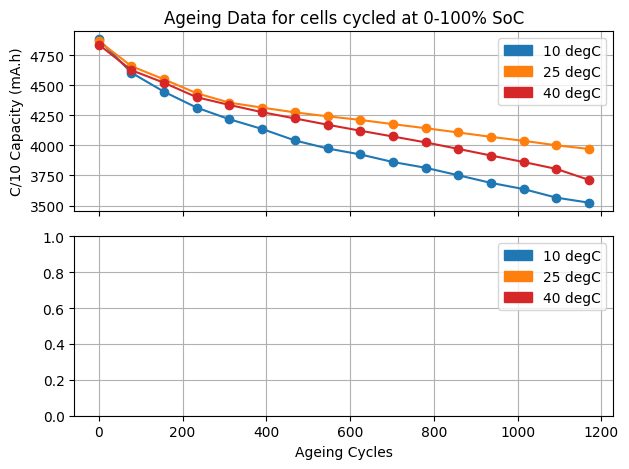

In [98]:
fig_0p1C_dis, ax = plt.subplots(2, sharex=True)

expt = 'Expt 5'
cell = 'E'

x_variable = 'Ageing Cycles'
y_variable_1 = 'C/10 Capacity (mA.h)'
y_variable_2 = '0.1s Resistance (Ohms)'

for cell in meta_data_dict[expt]['cell list']:
    temp_val = meta_data_dict[expt]['Temperature dict'][cell]
    data_dict[expt]['Main'][cell].plot(x_variable, y_variable_1, ax=ax[0], c=colour_temp_dict[temp_val], marker='o')
    df_slice = data_dict[expt]['Main'][cell].loc[range(0,len(data_dict[expt]['Main'][cell]), 2), :]
    #df_slice.plot(x_variable, y_variable_2, ax=ax[1], c=colour_temp_dict[temp_val], marker='o')

ax[1].set_xlabel(x_variable)
ax[0].set_ylabel(y_variable_1)
# ax[1].set_ylabel(y_variable_2)
ax[0].grid(True)
ax[1].grid(True)
SOC_val = meta_data_dict[expt]['SoC Range']
ax[0].set_title(f'Ageing Data for cells cycled at {SOC_val}% SoC')

colours = colour_temp_dict
labels = [f'{temp_value} degC' for temp_value in colour_temp_dict.keys()]
handles = [plt.Rectangle((0,0),1,1, color=colours[entry]) for entry in colour_temp_dict.keys()]
ax[0].legend(handles, labels, loc='best')
ax[1].legend(handles, labels, loc='best')

fig_0p1C_dis.tight_layout()

In [99]:
colour_temp_dict

{10: 'C0', 25: 'C1', 40: 'C3'}

Text(0.5, 1.0, 'Ageing Data for cells cycled at 0-100% SoC')

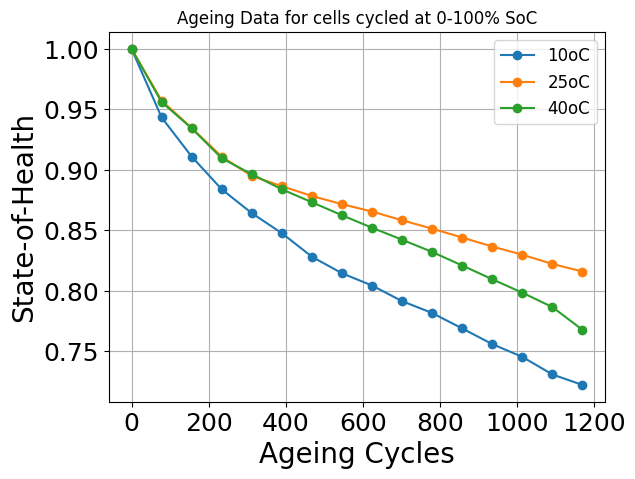

In [103]:
expt = 'Expt 5'
cell = 'E'

x_variable = 'Ageing Cycles'
y_variable_1 = 'C/10 Capacity (mA.h)'
y_variable_2 = '0.1s Resistance (Ohms)'

colours = colour_temp_dict
labels = [f'{temp_value} degC' for temp_value in colour_temp_dict.keys()]

for cell in meta_data_dict[expt]['cell list']:
    temp_val = meta_data_dict[expt]['Temperature dict'][cell]
    soh = data_dict[expt]['Main'][cell][y_variable_1]/data_dict[expt]['Main'][cell][y_variable_1][0]
    plt.plot(data_dict[expt]['Main'][cell][x_variable], soh, label = f"{temp_val}oC", marker='o' )

plt.legend(fontsize=12)

plt.xlabel(x_variable,fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
# plt.title('SoH of a Lithium-Ion Cell-DFN Model',fontsize=20)
#plt.ylim([75, 101])
# #plt.xlim([-50, 500]) 
# plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)

SOC_val = meta_data_dict[expt]['SoC Range']
plt.title(f'Ageing Data for cells cycled at {SOC_val}% SoC')

In [44]:
plt.show()

In [14]:
fig_0p1C_dis.show()

In [32]:
print(matplotlib.get_backend())

inline
